# Inter-Node Analysis

This notebook loads a benchmark's capability tree and analyzes the differences between:

1. Model ranking on the full benchmark vs each node
2. Model performance on the full benchmark vs each node

Import packages.

In [259]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from collections import Counter, defaultdict
from scipy.stats import kendalltau, rankdata
from tqdm import tqdm
from src.utils.capability_tree import (
    align_rankings,
    collect_nodes,
    load_capability_tree,
)
from src.utils.enums import Dataset
from src.utils.path import build_plot_path
from src.utils.plot import plot_histogram

Specify the benchmark, load it's capability tree, and collect the tree's nodes.

In [260]:
dataset = Dataset.CHATBOT_ARENA
root = load_capability_tree(dataset)

min_instances = 50
global_ranking = root["ranking"]
nodes = collect_nodes(root, min_instances)

num_models = len(global_ranking)
print(f"Number of models: {num_models}")
print(f"Found {len(nodes)} nodes (non-root, size > {min_instances} instances)")

Number of models: 64
Found 790 nodes (non-root, size > 50 instances)


### Model Ranking Analysis

Compute the Kendall's Tau between each node's local model ranking and the global model ranking.

In [261]:
taus = np.zeros(len(nodes))

kwargs = {
    "desc": "Computing Kendall's Taus",
    "total": len(nodes),
    "unit": "node",
}

for i, node in tqdm(enumerate(nodes), **kwargs):
    if node["ranking"] is None:
        continue
    aligned_global, aligned_local = align_rankings(
        global_ranking,
        node["ranking"],
    )
    tau, _ = kendalltau(aligned_global, aligned_local)
    taus[i] = tau

Computing Kendall's Taus: 100%|██████████| 790/790 [00:00<00:00, 9795.34node/s]


Plot a histogram of the Kendall's Taus bewteen each node's model ranking and the global model ranking.

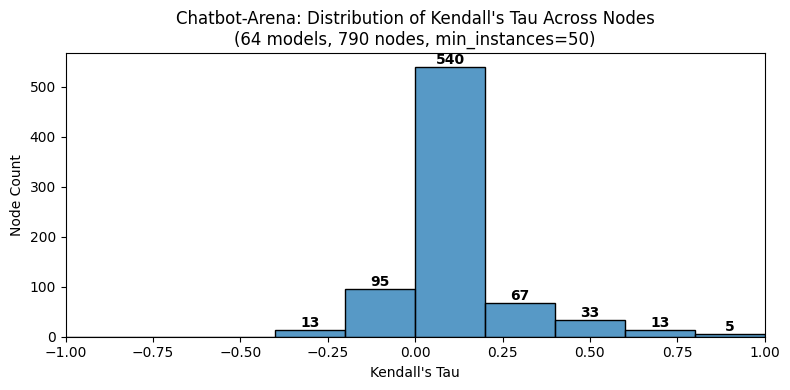

In [262]:
xlabel = "Kendall's Tau"
ylabel = "Node Count"
title = (
    f"{dataset}: Distribution of Kendall's Tau Across Nodes"
    f"\n({num_models} models, {len(nodes)} nodes, min_instances={min_instances})"
)
annotate = True
xlim = (-1, 1)

plot_histogram(
    taus,
    xlabel=xlabel,
    ylabel=ylabel,
    title=title,
    annotate=annotate,
    mean=taus.mean(),
    std=taus.std(),
    xlim=xlim,
)

analysis = "inter_node_analysis"
sub_analysis = "model_ranking"
plot_name = f"kendall_tau_distribution-min_instances={min_instances}"
plot_path = build_plot_path(
    dataset,
    analysis=analysis,
    sub_analysis=sub_analysis,
    plot_name=plot_name,
)
plt.savefig(plot_path)
plt.show()

Plot a bar chart showing each model's standard deviation in rank across all nodes.

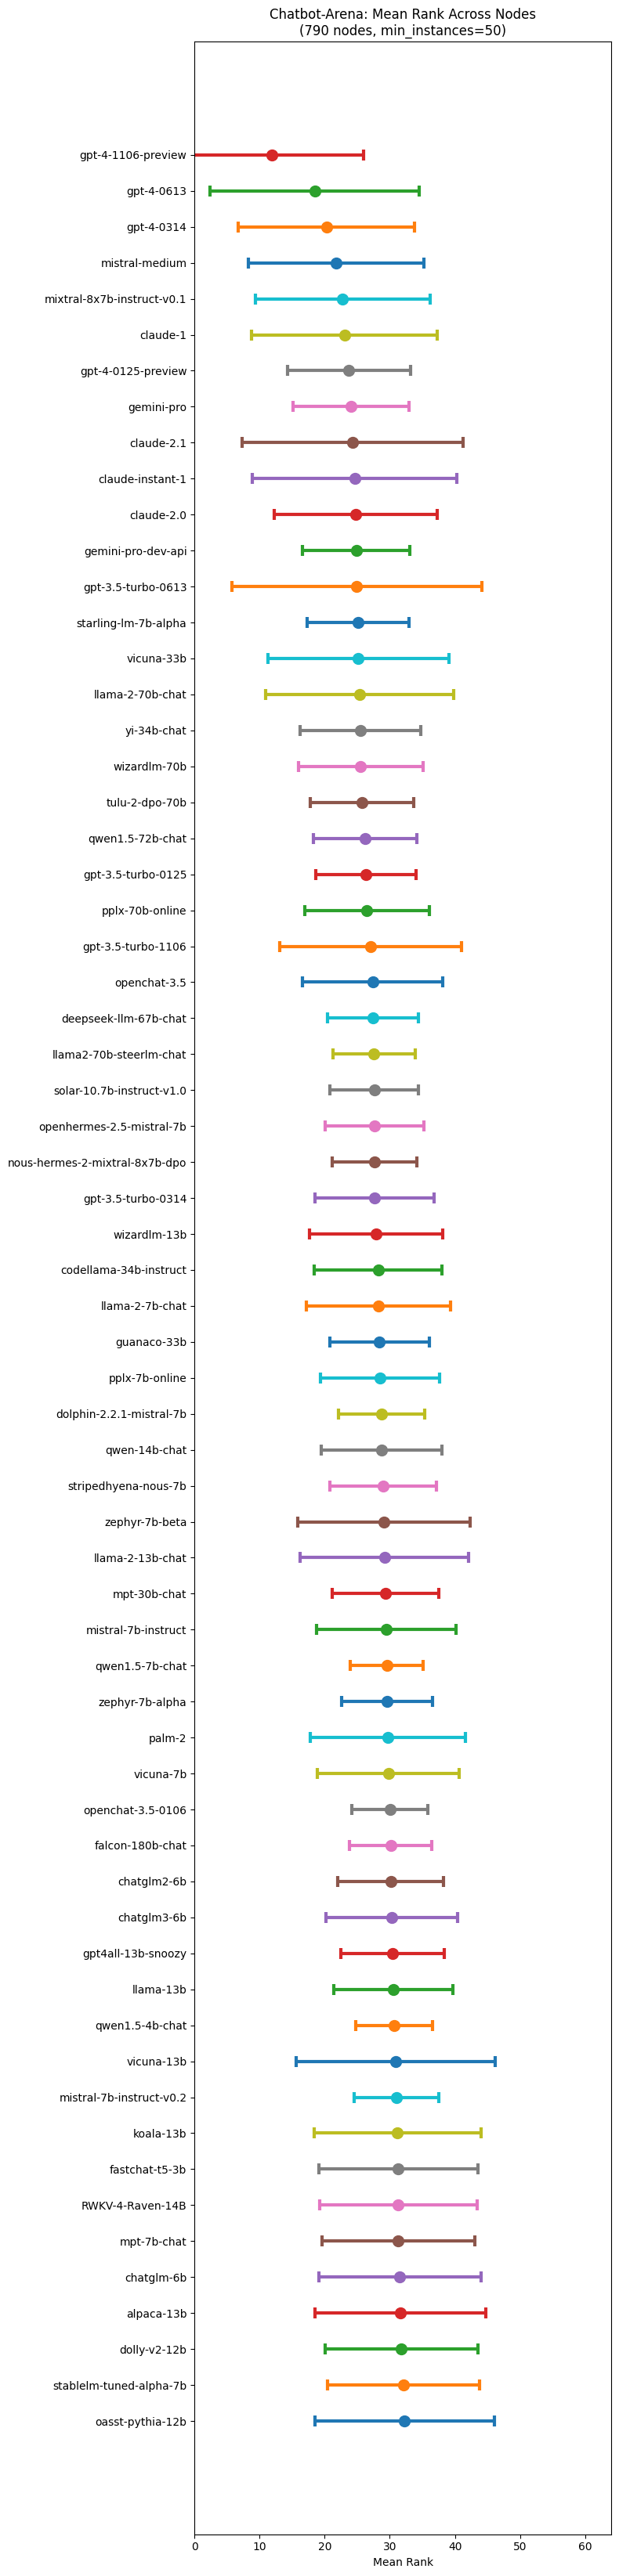

In [263]:
models = [model for model, _ in global_ranking]

# Store each model's per-node ranks
model_node_ranks = defaultdict(list)

# For each node, extract model names and per-node scores
for node in nodes:
    if node["ranking"] is None:
        continue

    # Extract model names and their scores for the current node
    node_models = [model for model, _ in node["ranking"]]
    node_scores = np.array([score for _, score in node["ranking"]])

    # Higher is better for all metrics
    ranks = rankdata(-node_scores, method="average")

    # Store each model's rank for the current node
    for model, rank in zip(node_models, ranks):
        model_node_ranks[model].append(rank)

# Compute mean and std of rank for each model
model_to_rank_mean = {model: np.mean(model_node_ranks[model]) for model in models}
model_to_rank_std = {model: np.std(model_node_ranks[model]) for model in models}

# Sort by mean rank ascending (best rank at top)
sorted_models = sorted(models, key=lambda m: model_to_rank_mean[m], reverse=True)

means = [model_to_rank_mean[m] for m in sorted_models]
stds = [model_to_rank_std[m] for m in sorted_models]
colors = sns.color_palette("tab10", n_colors=len(sorted_models))

xlabel = "Mean Rank"
title = (
    f"{dataset}: Mean Rank Across Nodes"
    f"\n({len(nodes)} nodes, min_instances={min_instances})"
)

fig, ax = plt.subplots(figsize=(8, len(models) * 0.5 + 1))
for i, (model, mean, std, color) in enumerate(zip(sorted_models, means, stds, colors)):
    ax.errorbar(
        mean,
        i,
        xerr=std,
        fmt="o",
        color=color,
        markersize=10,
        capsize=5,
        elinewidth=3,
        capthick=3,
    )
ax.set_yticks(range(len(sorted_models)))
ax.set_yticklabels(sorted_models)
ax.set_xlabel(xlabel)
ax.set_title(title)
ax.set_xlim(0, num_models)
fig.tight_layout()

plot_name = f"all_models-rank_mean_std-min_instances={min_instances}"
plot_path = build_plot_path(
    dataset,
    analysis=analysis,
    sub_analysis=sub_analysis,
    plot_name=plot_name,
)
fig.savefig(plot_path)
plt.show()

Count the number of unique model rankings across all nodes and the number of instances they occur.

In [264]:
# For each node, extract the ordered model ranking as a tuple
node_rankings = []
for node in nodes:
    if node["ranking"] is None:
        continue
    ranking_tuple = tuple(model for model, _ in node["ranking"])
    node_rankings.append(ranking_tuple)

# Count occurrences of each unique ranking
ranking_counts = Counter(node_rankings)

# Store in a DataFrame sorted by frequency descending
rankings_df = pd.DataFrame(
    [(list(ranking), count) for ranking, count in ranking_counts.most_common()],
    columns=["ranking", "count"],
)

print(f"Total nodes: {len(node_rankings)}")
print(f"Unique rankings: {len(rankings_df)}")
rankings_df.head()

Total nodes: 406
Unique rankings: 395


,ranking,count
0,"[mixtral-8x7b-instruct-v0.1, chatglm-6b, claud...",3
1,"[gpt-4-1106-preview, claude-instant-1, RWKV-4-...",3
2,"[gpt-3.5-turbo-0613, RWKV-4-Raven-14B, chatglm...",2
3,"[vicuna-33b, alpaca-13b, RWKV-4-Raven-14B, cha...",2
4,"[vicuna-33b, alpaca-13b, RWKV-4-Raven-14B, cha...",2


### Model Performance Analysis

Plot a histogram showing the distribution of each model's performance across all nodes.

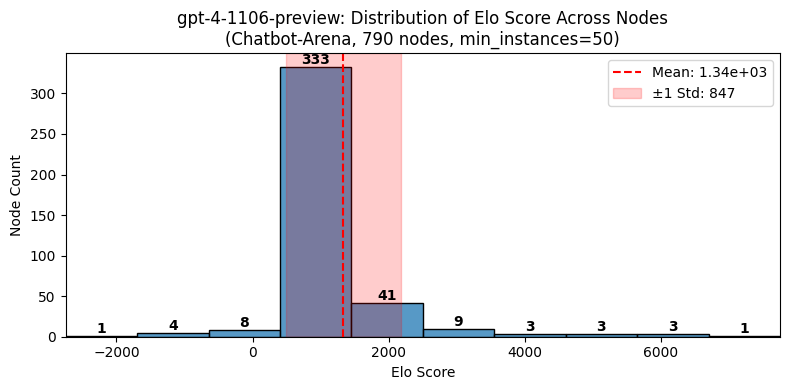

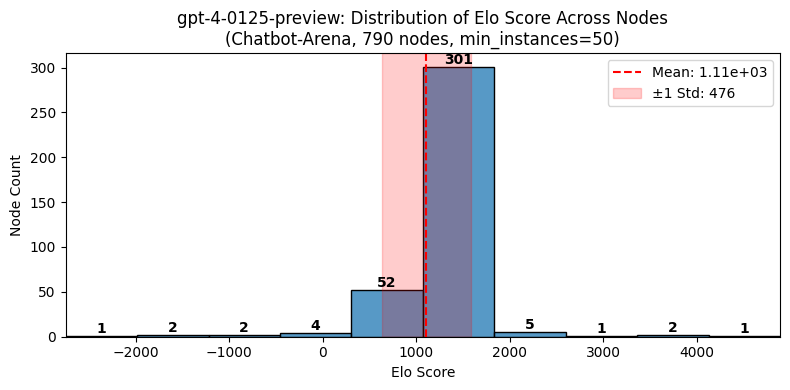

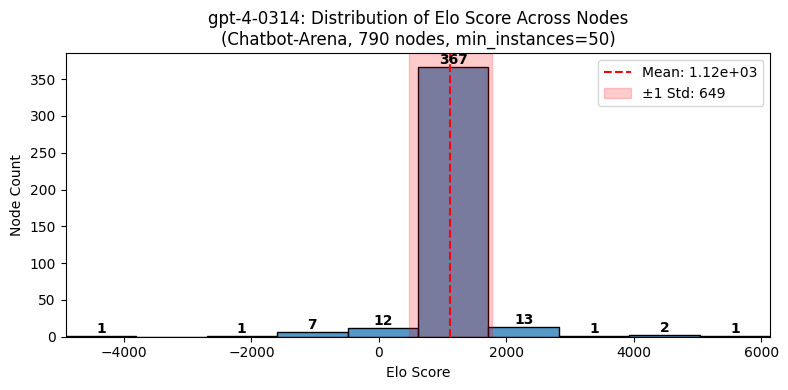

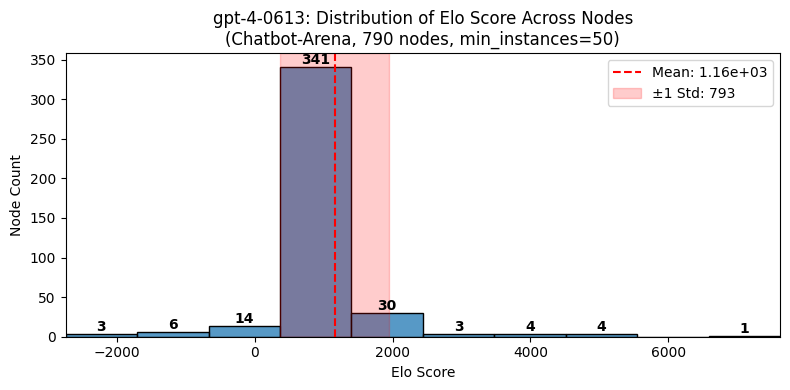

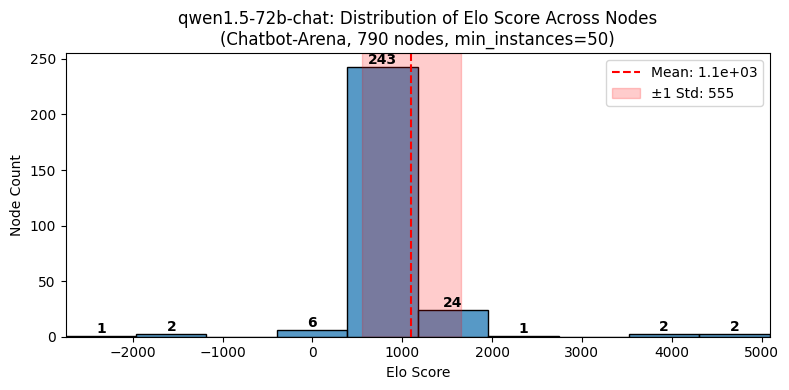

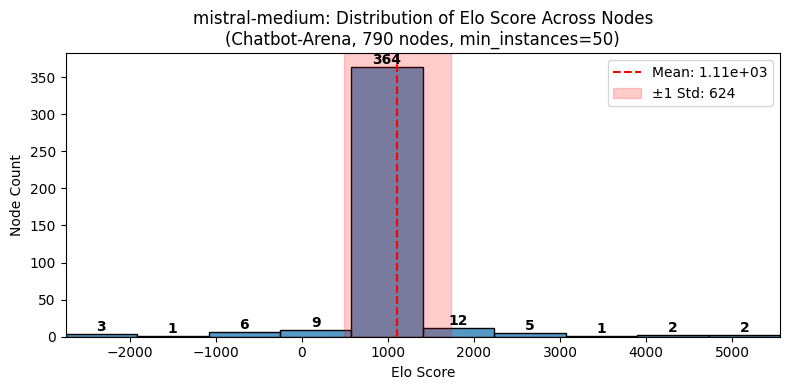

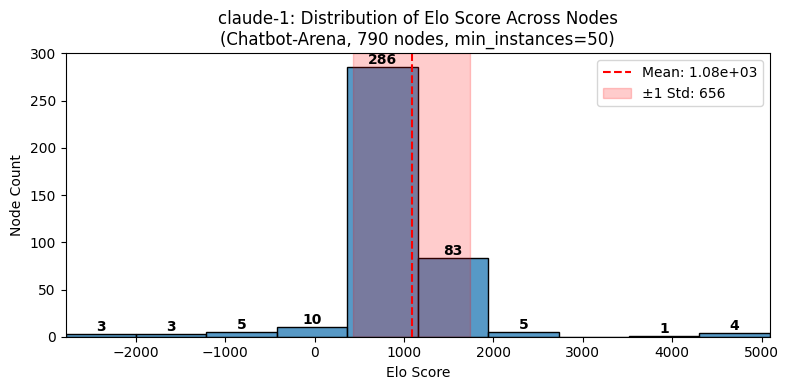

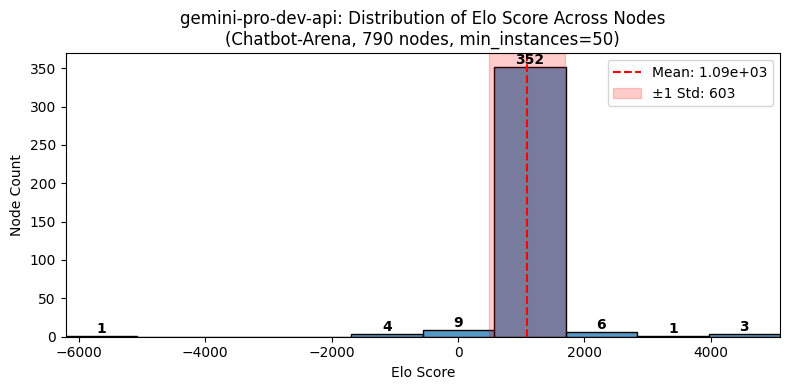

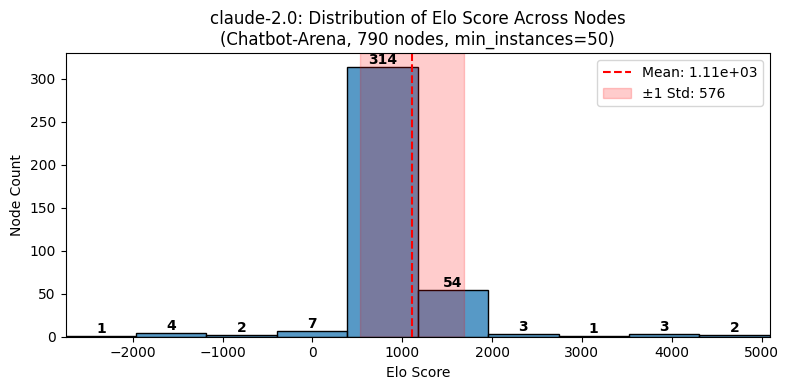

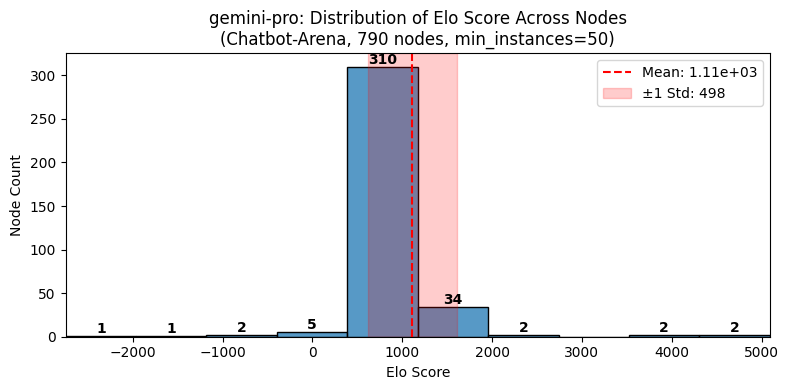

C:\Users\Mike\vscode\EvalTree\src\utils\plot.py:53: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(data_min, data_max)


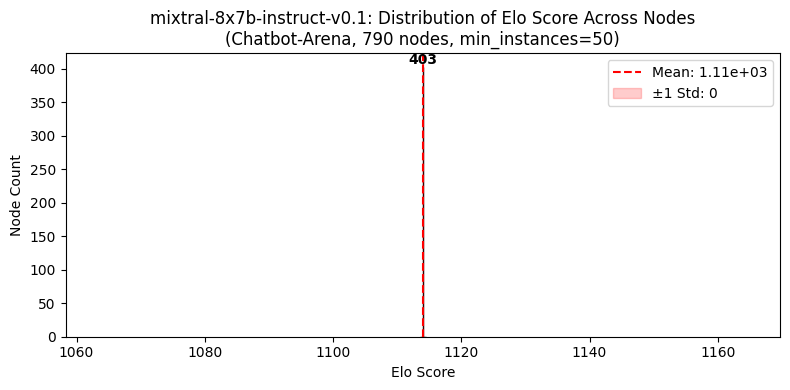

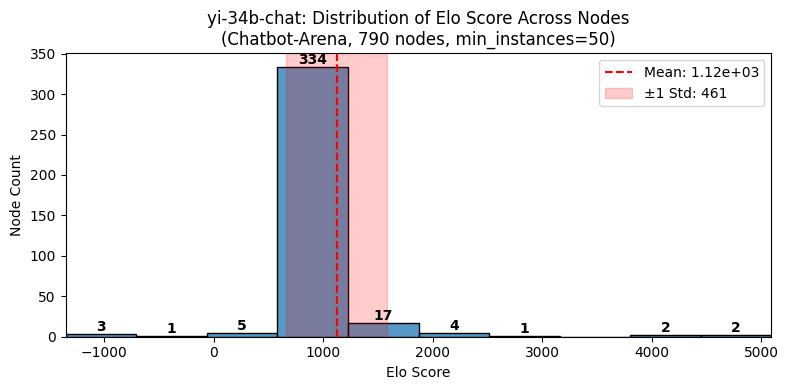

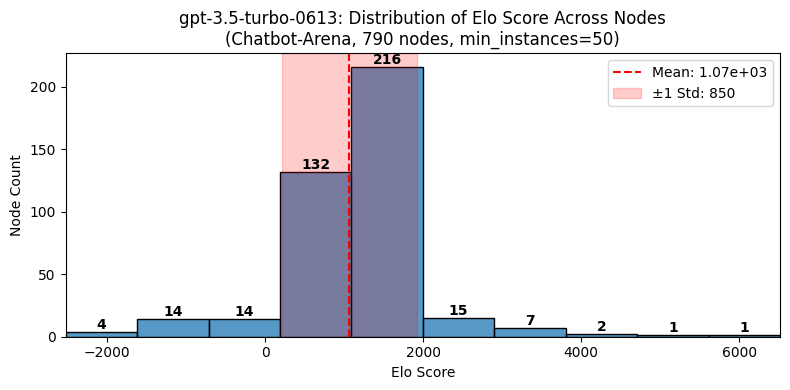

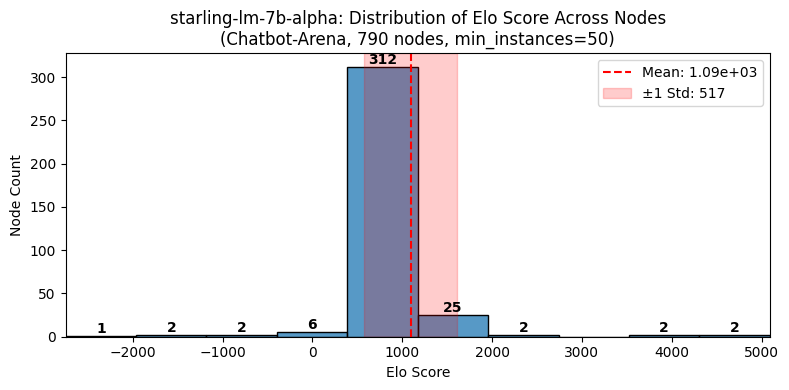

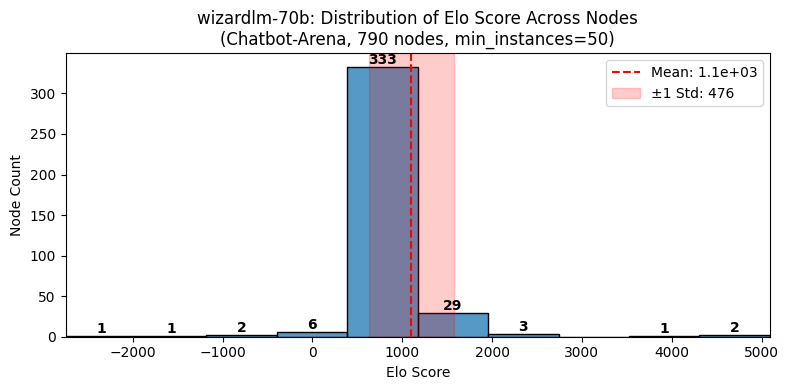

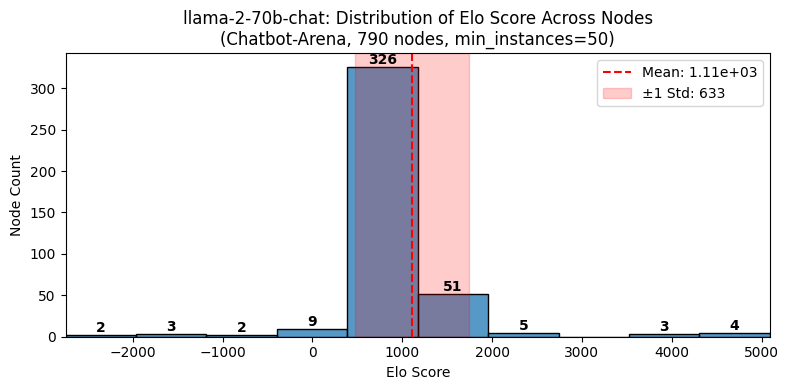

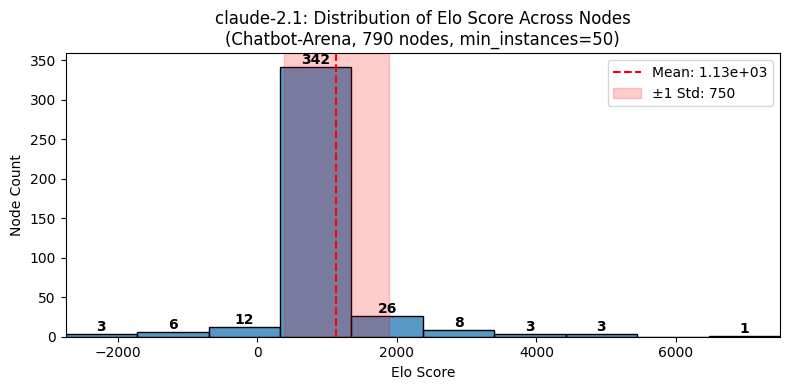

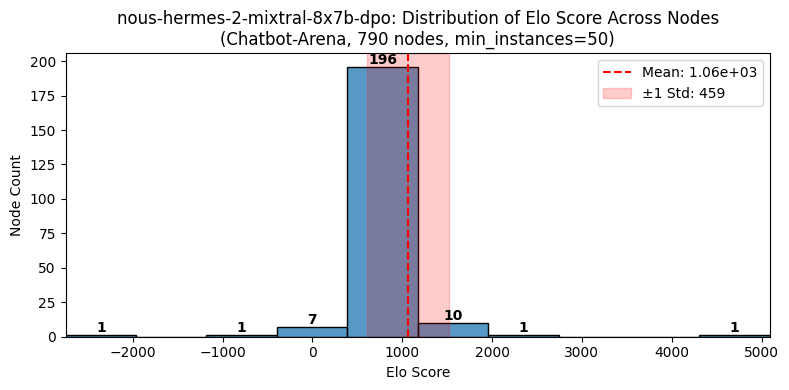

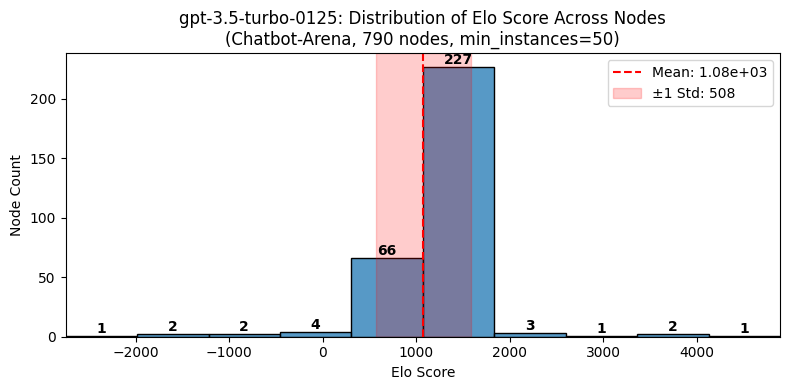

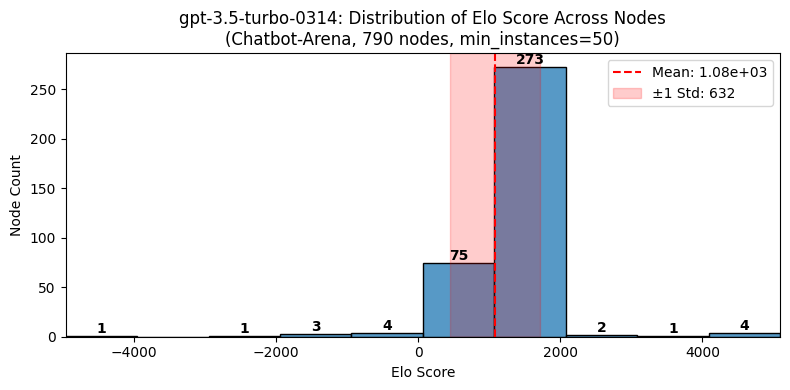

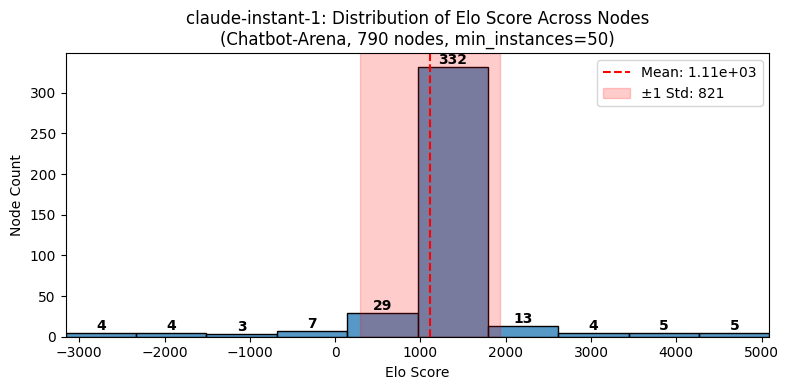

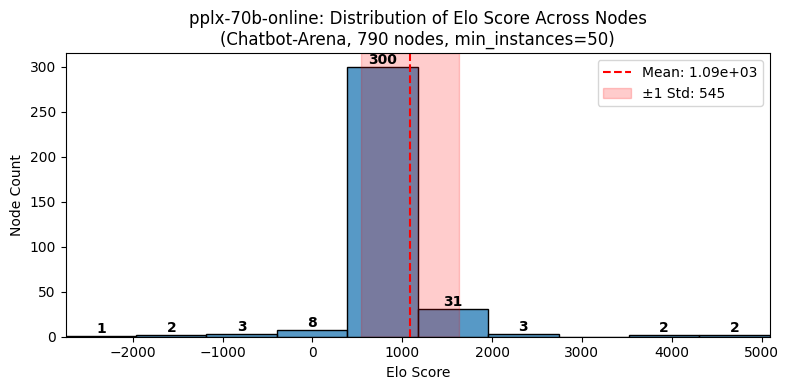

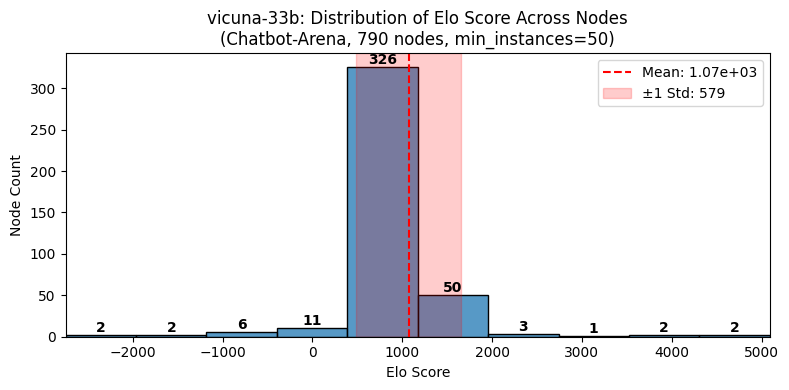

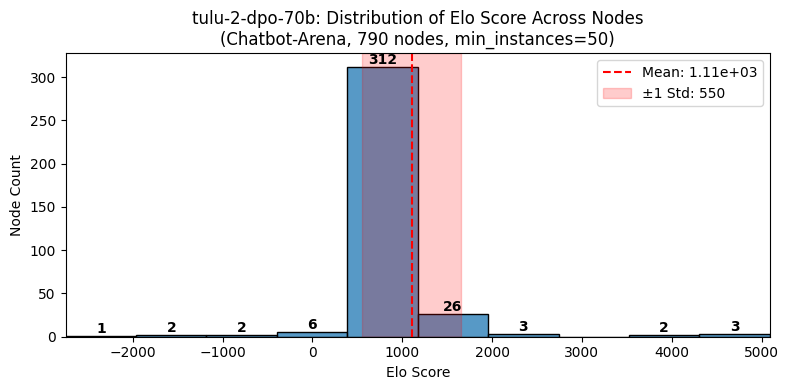

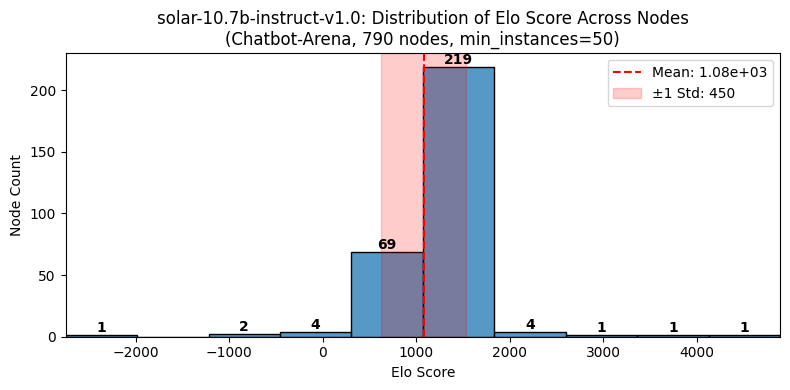

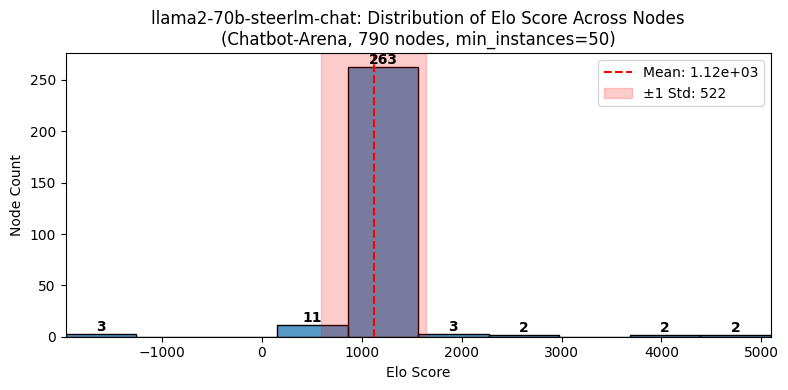

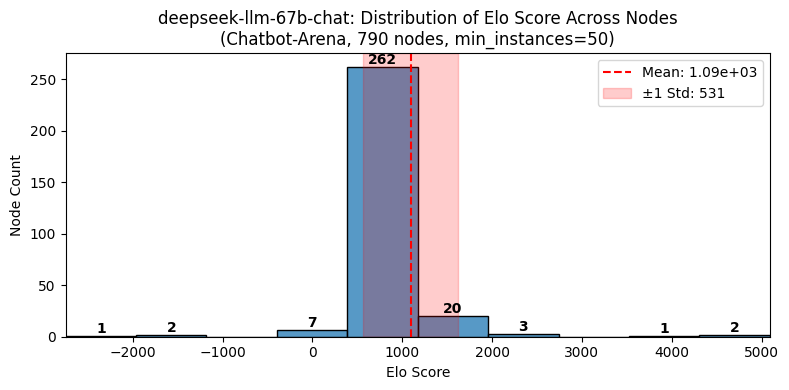

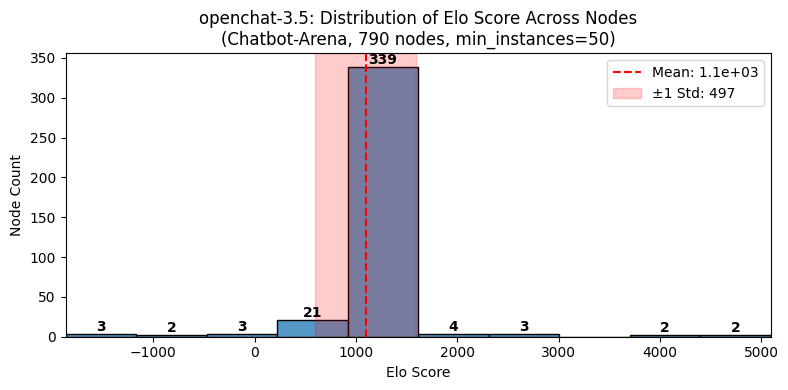

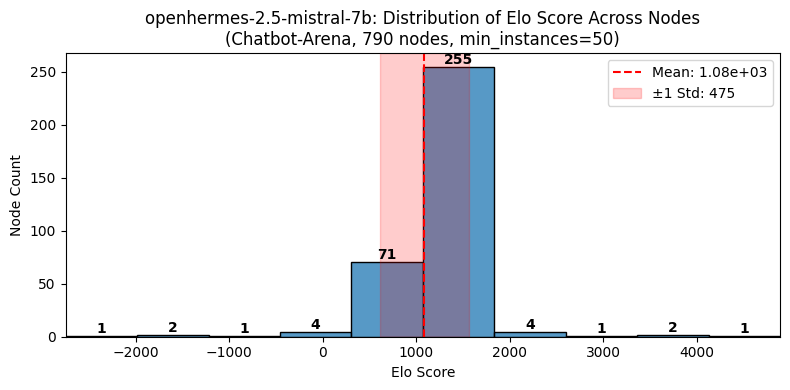

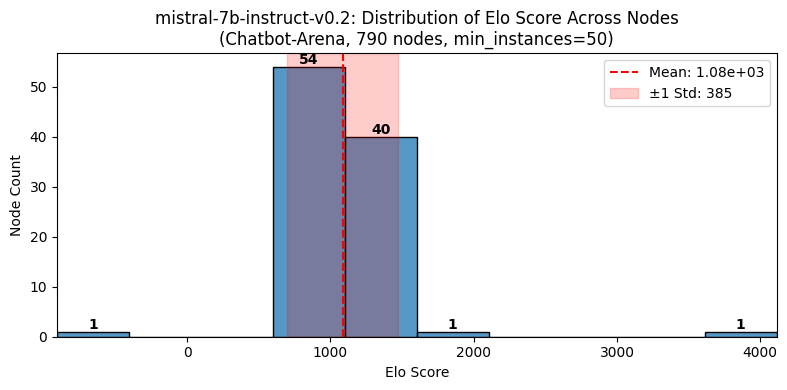

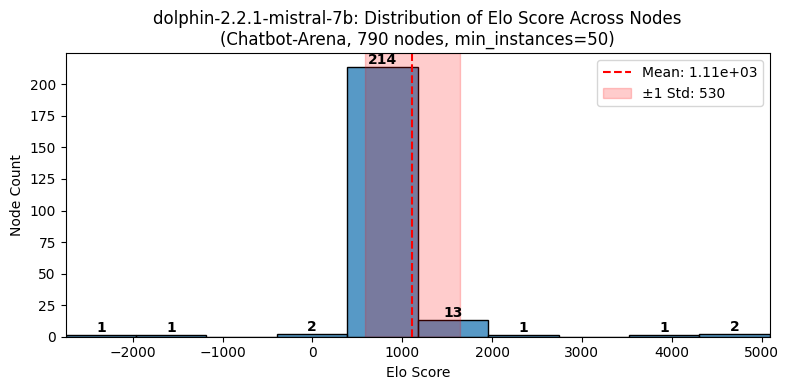

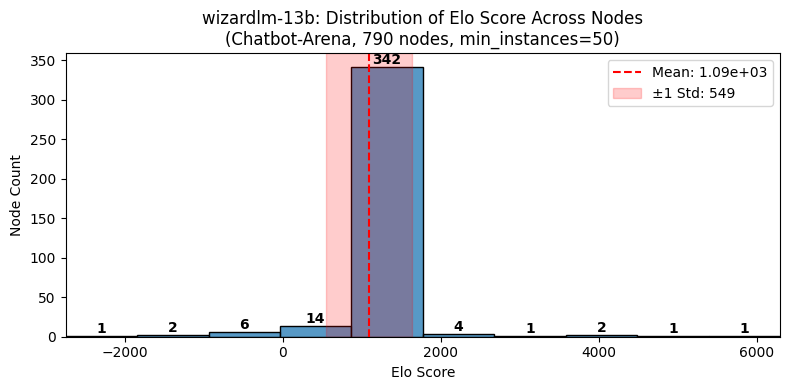

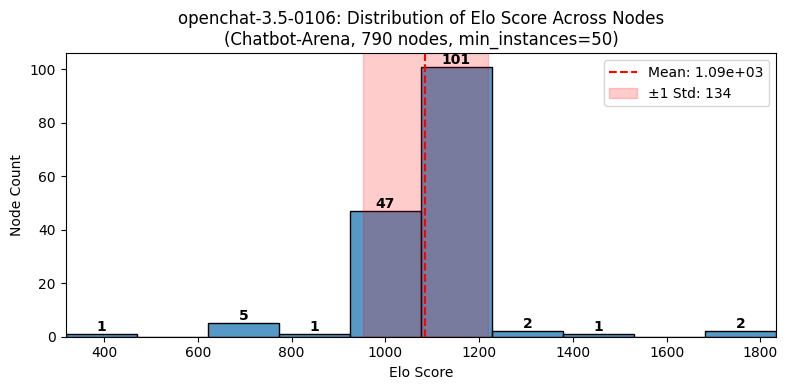

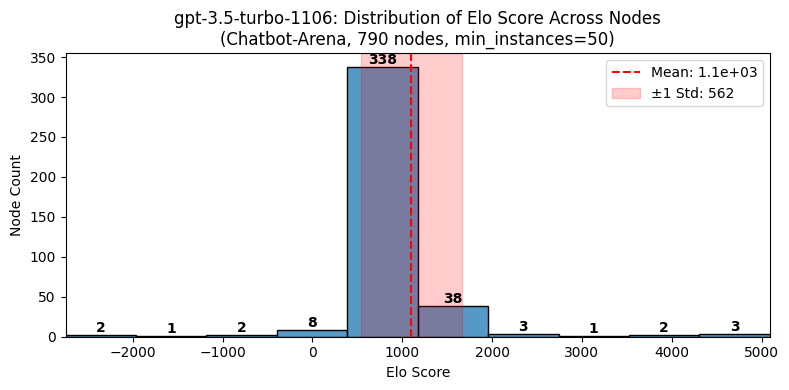

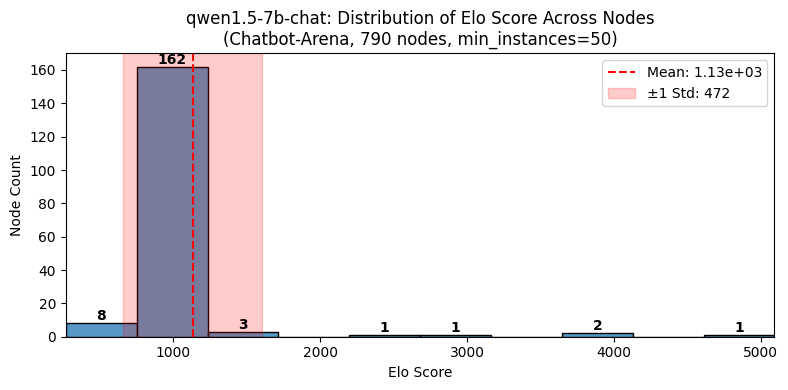

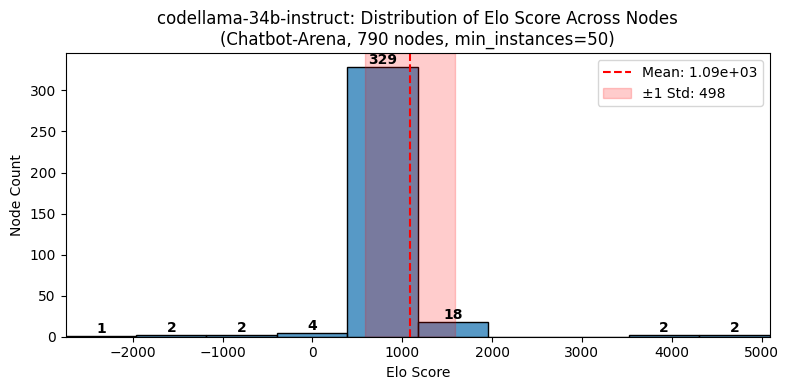

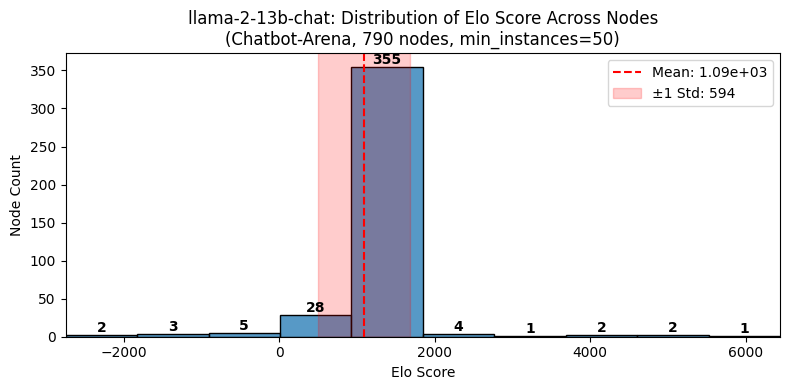

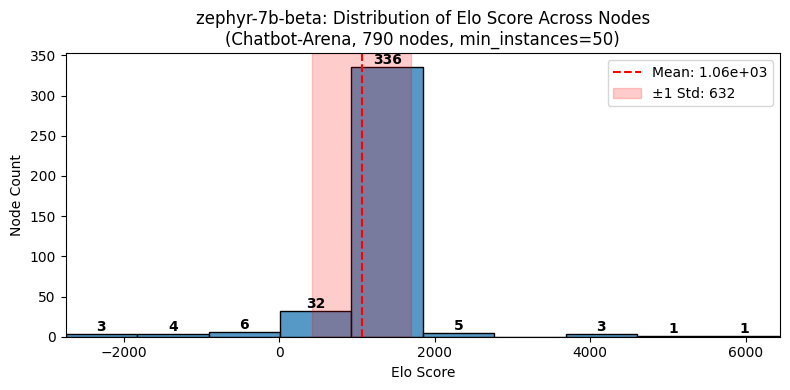

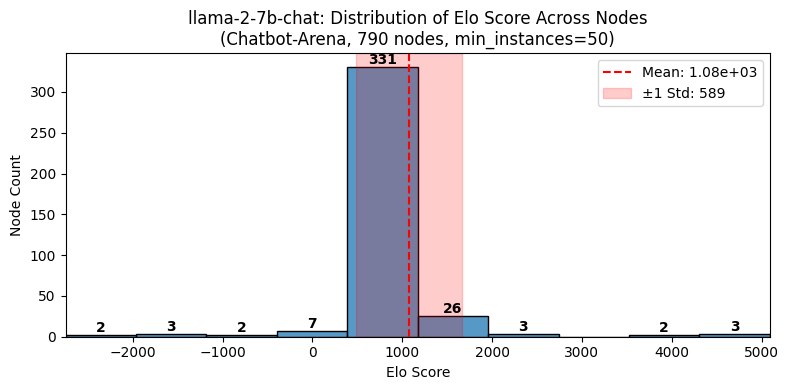

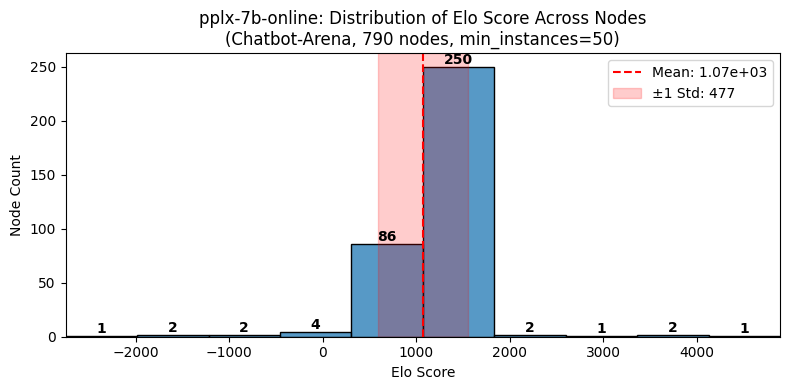

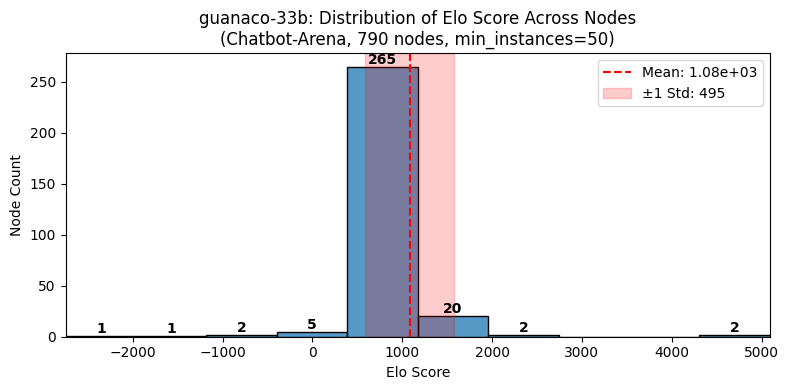

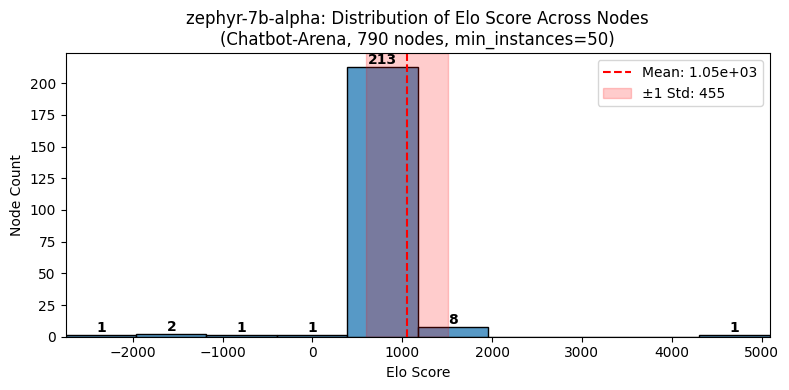

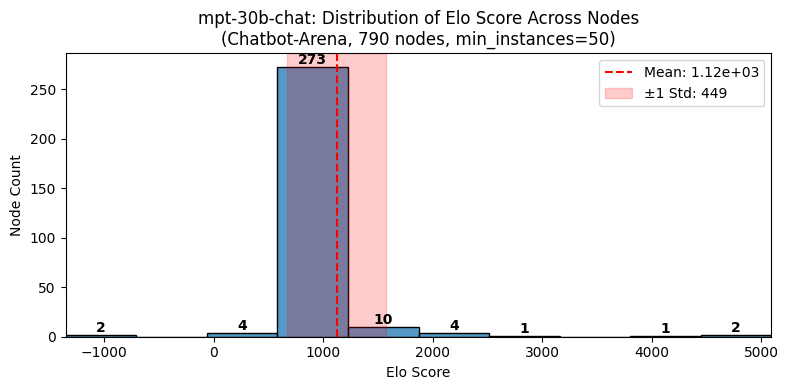

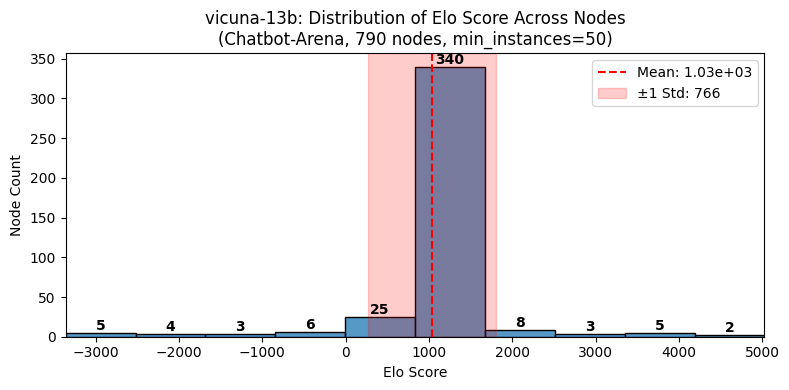

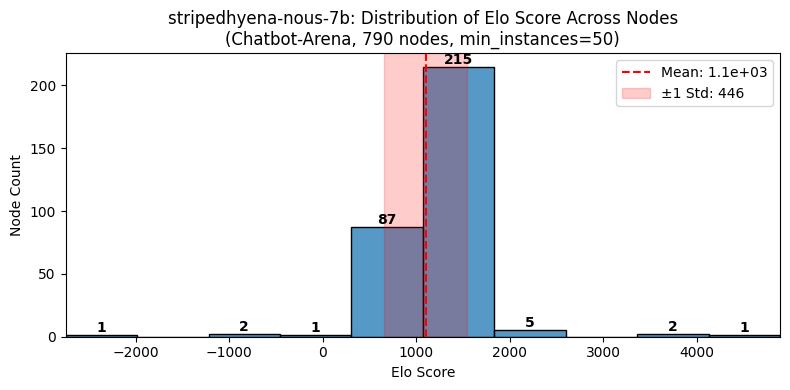

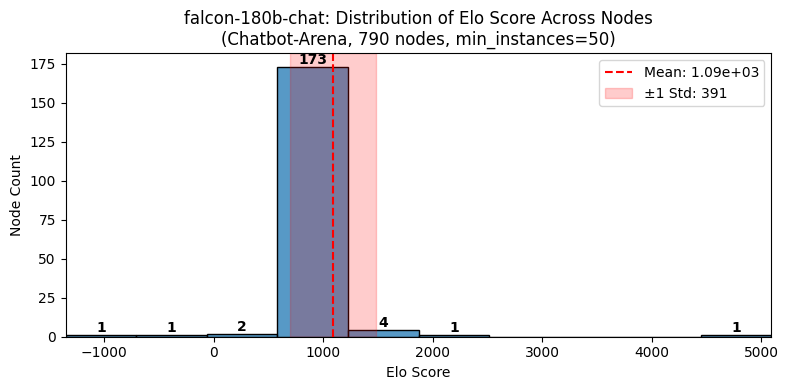

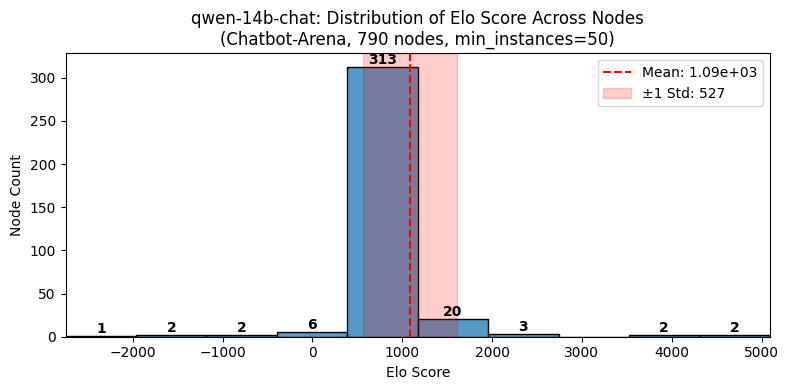

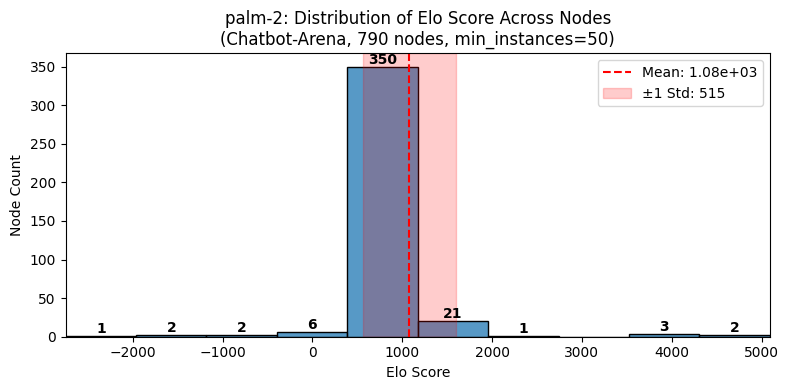

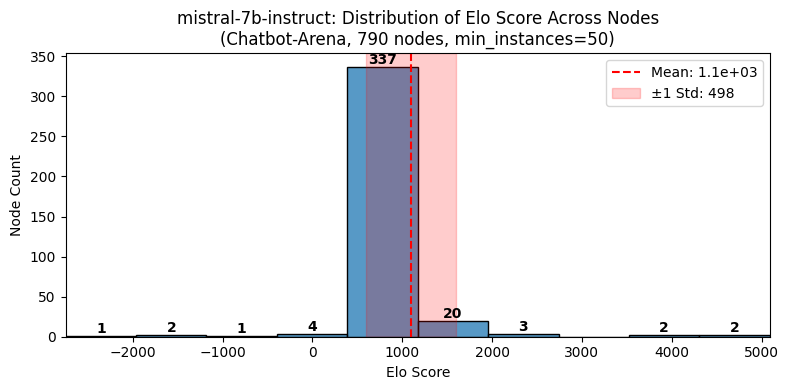

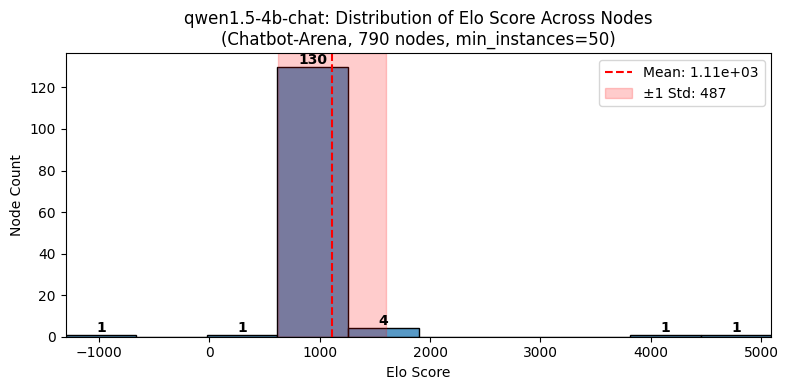

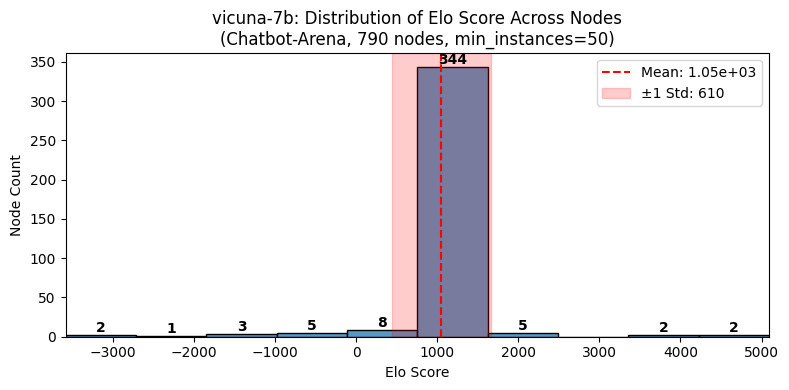

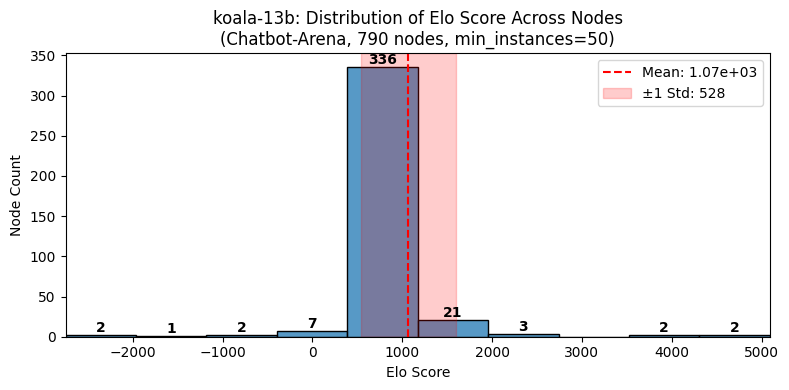

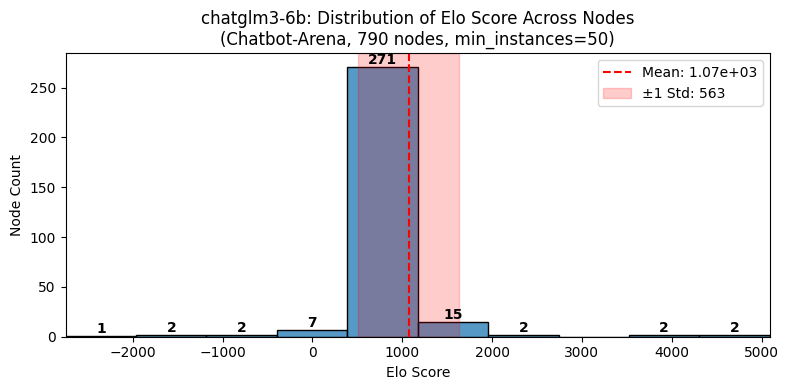

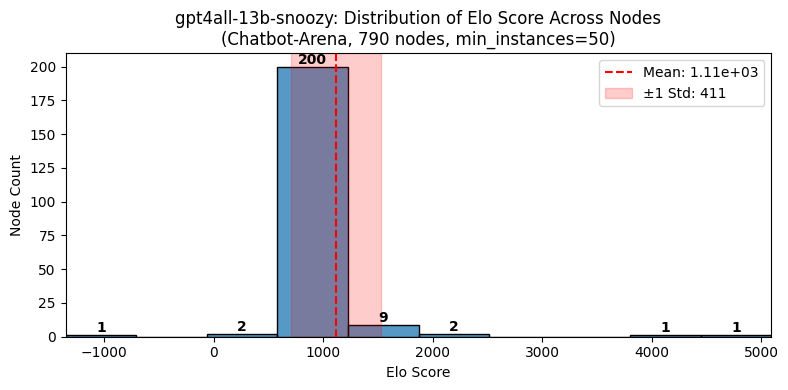

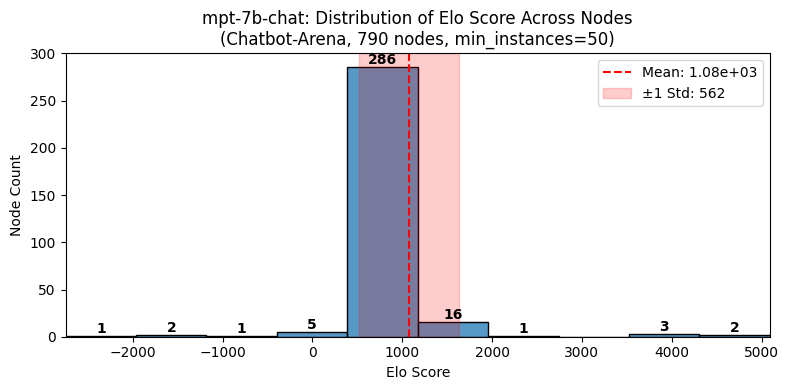

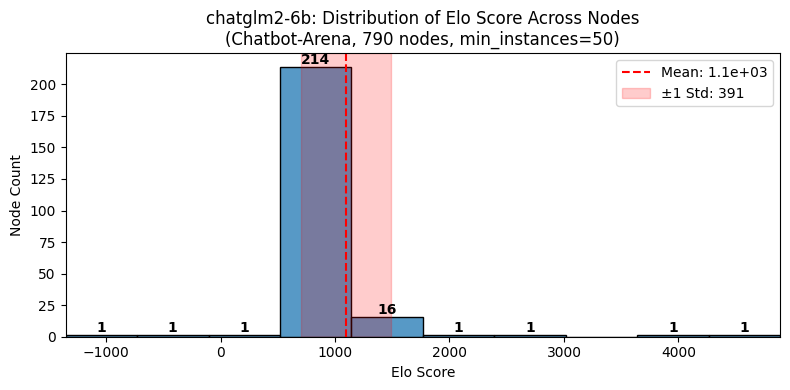

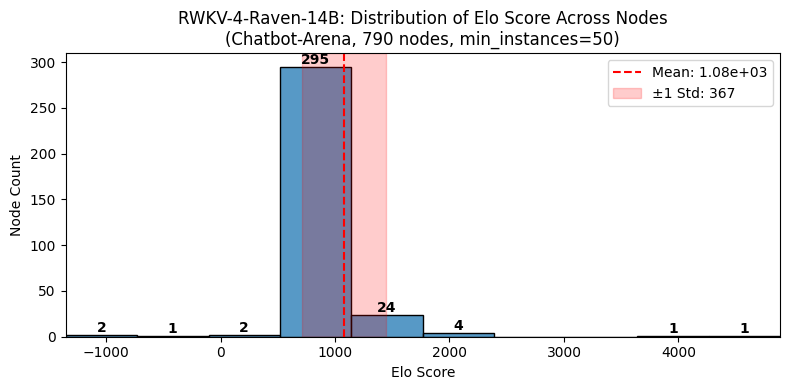

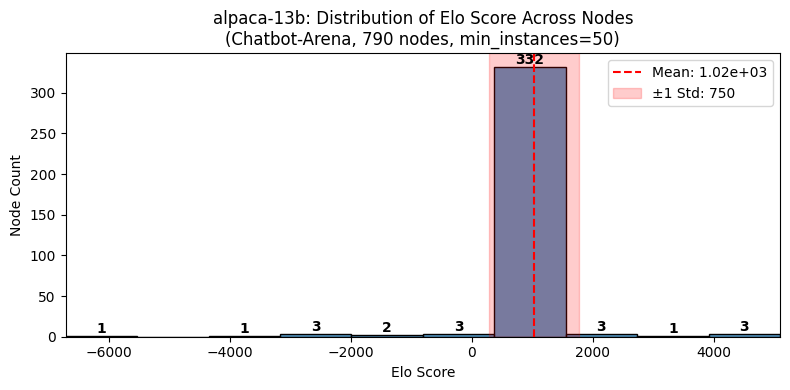

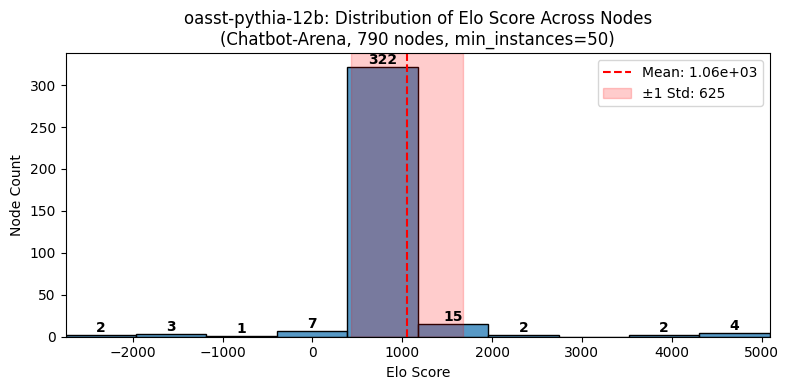

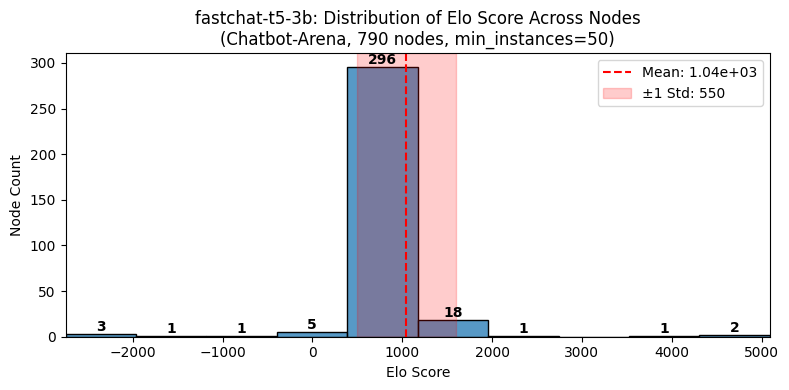

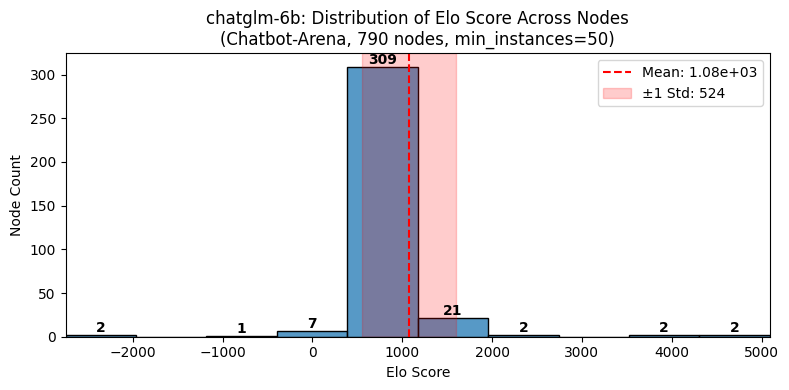

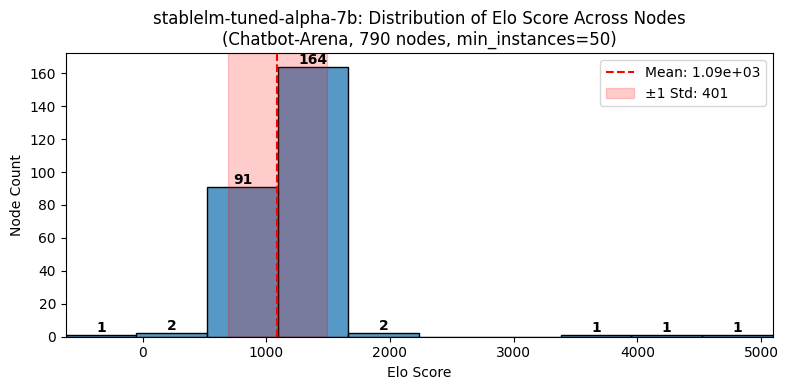

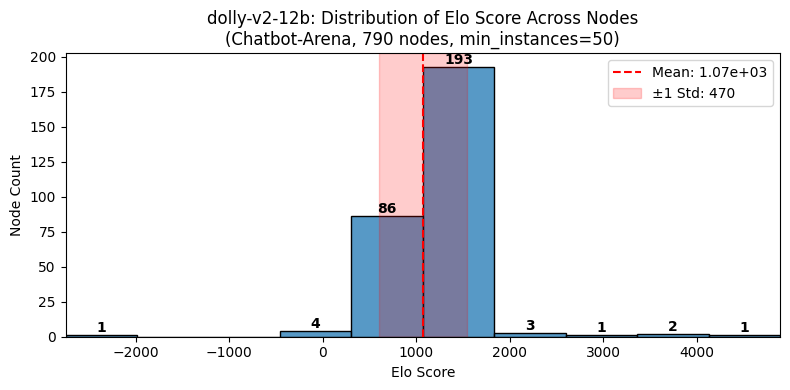

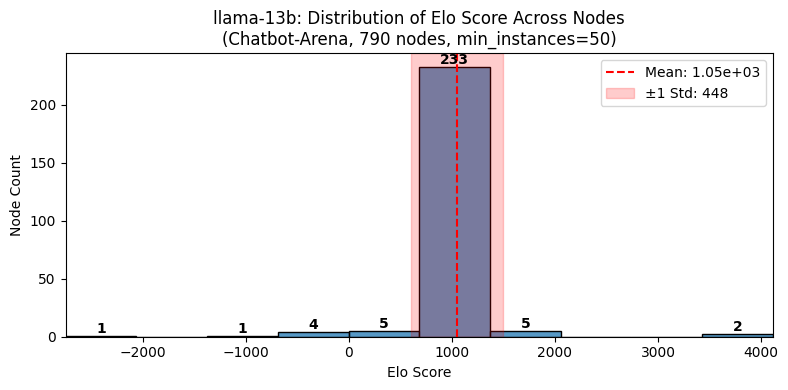

In [265]:
# Collect each model's per-node performances
model_scores = defaultdict(list)

for node in nodes:
    if node["ranking"] is None:
        continue
    for model, score in node["ranking"]:
        model_scores[model].append(score)

for model in models:
    scores = np.array(model_scores[model])
    metric = Dataset(dataset).metric
    xlabel = metric.title()
    ylabel = "Node Count"
    title = (
        f"{model}: Distribution of {metric.title()} Across Nodes"
        f"\n({dataset}, {len(nodes)} nodes, min_instances={min_instances})"
    )
    annotate = True
    mean = scores.mean()
    std = scores.std()

    # # Elo score is the only metric that isn't restricted to [0, 1]
    xlim = (0, 1) if metric != "Elo score" else None

    fig = plot_histogram(
        scores,
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        annotate=annotate,
        mean=mean,
        std=std,
        # xlim=xlim,
    )

    plot_name = f"{model}-performance_distribution-min_instances={min_instances}"
    sub_analysis = "model_performance"
    plot_path = build_plot_path(
        dataset,
        analysis=analysis,
        sub_analysis=sub_analysis,
        plot_name=plot_name,
    )
    fig.savefig(plot_path)
    plt.show()

Plot a bar chart showing each model's standard deviation in performance across all nodes.

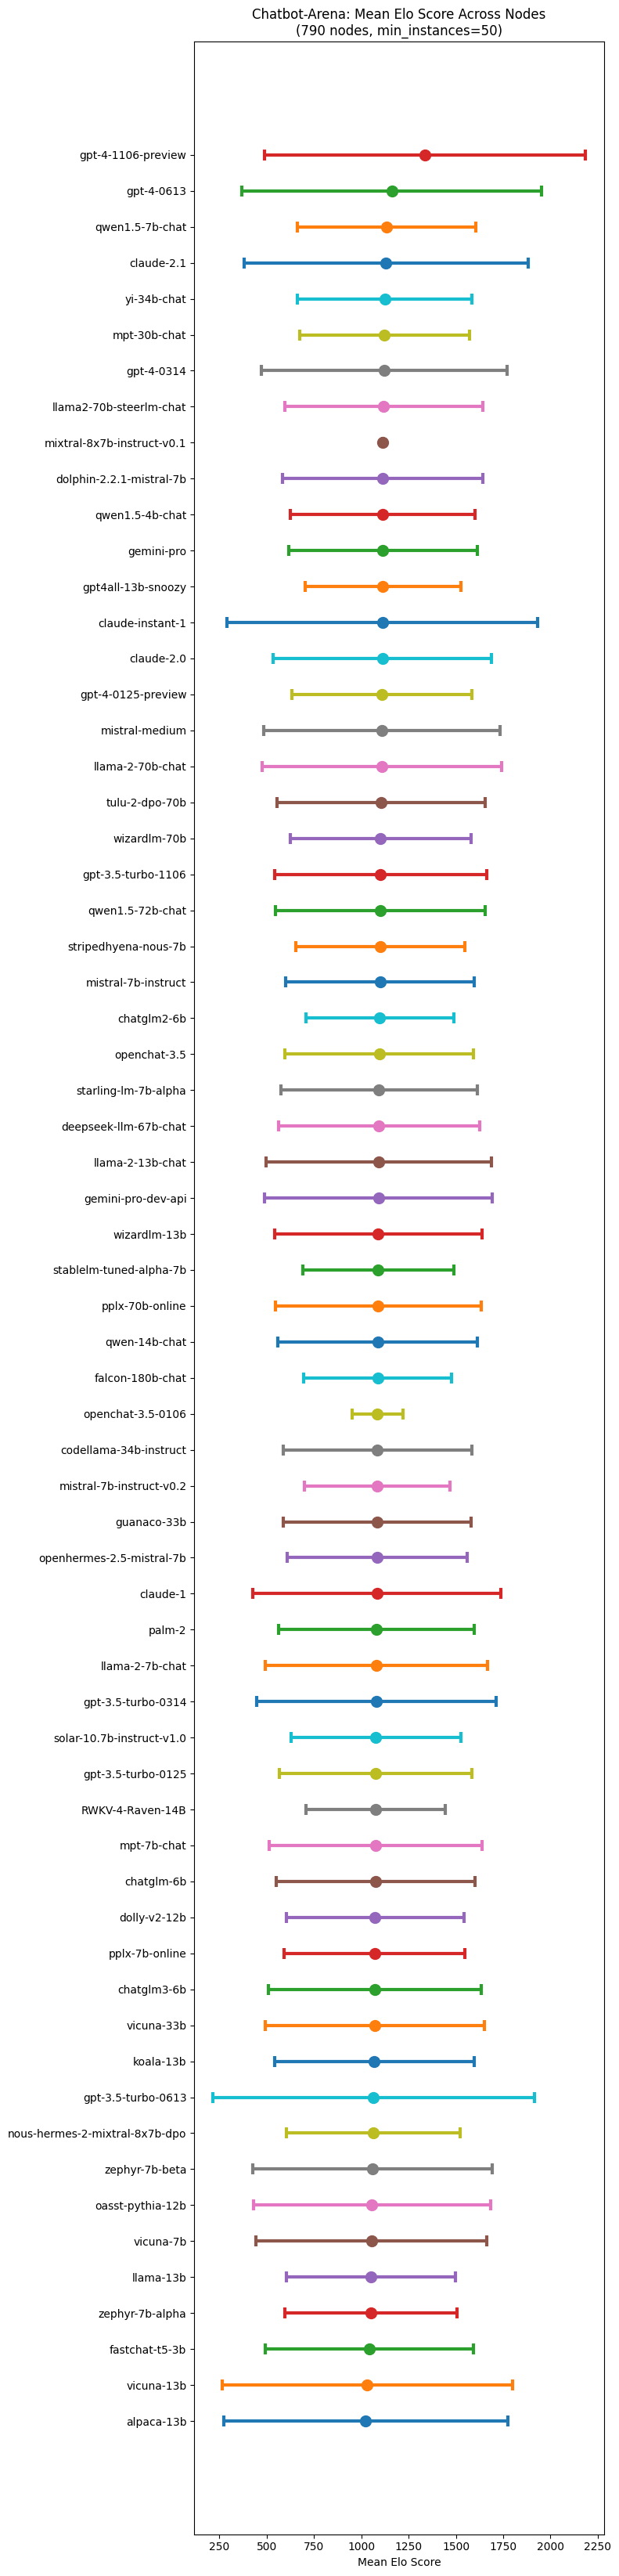

In [266]:
# Compute mean and std of performance across nodes for each model
model_to_performance_mean = {model: np.mean(model_scores[model]) for model in models}
model_to_performance_std = {model: np.std(model_scores[model]) for model in models}

# Sort by mean performance ascending (highest at top)
sorted_models = sorted(models, key=lambda m: model_to_performance_mean[m])

means = [model_to_performance_mean[m] for m in sorted_models]
stds = [model_to_performance_std[m] for m in sorted_models]
colors = sns.color_palette("tab10", n_colors=len(sorted_models))

xlabel = f"Mean {metric.title()}"
title = (
    f"{dataset}: Mean {metric.title()} Across Nodes"
    f"\n({len(nodes)} nodes, min_instances={min_instances})"
)

fig, ax = plt.subplots(figsize=(8, len(models) * 0.5 + 1))
zipped = zip(sorted_models, means, stds, colors)
for i, (model, mean, std, color) in enumerate(zipped):
    ax.errorbar(
        mean,
        i,
        xerr=std,
        fmt="o",
        color=color,
        markersize=10,
        capsize=5,
        elinewidth=3,
        capthick=3,
    )
ax.set_yticks(range(len(sorted_models)))
ax.set_yticklabels(sorted_models)
ax.set_xlabel(xlabel)
ax.set_title(title)
# if Dataset(dataset).metric != "Elo score":
#     ax.set_xlim(0, 1)
fig.tight_layout()

plot_name = f"all_models-performance_mean_std-min_instances={min_instances}"
plot_path = build_plot_path(
    dataset,
    analysis=analysis,
    sub_analysis=sub_analysis,
    plot_name=plot_name,
)
fig.savefig(plot_path)
plt.show()